# Лабораторная работа  
## Тема: Машины опорных векторов (SVM)

### 1. Краткая информация о методе

Метод опорных векторов — это алгоритм классификации, который старается провести такую границу между классами, чтобы расстояние от этой границы до ближайших объектов было максимальным. Эти ближайшие объекты называются опорными векторами.

В данной работе решается задача бинарной классификации: по физико-химическим характеристикам и типу вина модель определяет, относится ли вино к хорошему качеству.

Для нелинейного разделения классов используется SVM с радиальной базисной функцией (`RBF`). Этот вариант хорошо подходит, когда зависимость между признаками и классом не является простой прямой линией.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, validation_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

plt.rcParams["figure.figsize"] = (10, 6)
sns.set_style("whitegrid")

### 2. Описание датасета

Используется датасет **Wine Quality**. В нём собраны характеристики красного и белого вина.  
Количество объектов: **6497**.

Основные признаки:
- fixed acidity — фиксированная кислотность;
- volatile acidity — летучая кислотность;
- citric acid — лимонная кислота;
- residual sugar — остаточный сахар;
- chlorides — хлориды;
- free sulfur dioxide — свободный диоксид серы;
- total sulfur dioxide — общий диоксид серы;
- density — плотность;
- pH — кислотность среды;
- sulphates — сульфаты;
- alcohol — содержание алкоголя;
- wine_type — тип вина.

Целевая переменная:
- `quality_label = 1` — хорошее вино;
- `quality_label = 0` — обычное или низкое качество.

Столбец `quality` в признаки не включается, потому что `quality_label` сформирован на его основе.


In [2]:
df = pd.read_csv("svm_wine_quality.csv")
print("Размер датасета:", df.shape)
df.head()

Размер датасета: (6497, 14)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type,quality_label
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,white,1
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,white,1
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,white,1
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,white,1
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,white,1


In [3]:
print("Информация о датасете:")
print(df.info())

print("\nПропуски по столбцам:")
print(df.isnull().sum())

Информация о датасете:
<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   str    
 13  quality_label         6497 non-null   int64  
dtypes: float64(11), int64(2), str(1)
memory usage: 710.7 KB
None

### 3. Предобработка данных

Для числовых признаков:
- пропуски заполняются медианой;
- далее выполняется стандартизация.

Стандартизация особенно важна для SVM, потому что метод чувствителен к масштабу признаков.

Для категориального признака `wine_type`:
- пропуски заполняются самым частым значением;
- затем признак переводится в числовой вид при помощи кодирования.


In [12]:
X = df.drop(columns=["quality_label", "quality"])
y = df["quality_label"]

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "string"]).columns.tolist()

print("Числовые признаки:", numeric_features)
print("Категориальные признаки:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

Числовые признаки: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Категориальные признаки: ['wine_type']
Размер обучающей выборки: (5522, 12)
Размер тестовой выборки: (975, 12)


### 4. Тепловая карта

Тепловая карта показывает коэффициенты корреляции между числовыми признаками и целевой переменной `quality_label`.

Корреляция показывает силу и направление линейной связи:
- ближе к `1` — сильная прямая связь;
- ближе к `-1` — сильная обратная связь;
- около `0` — связь слабая.


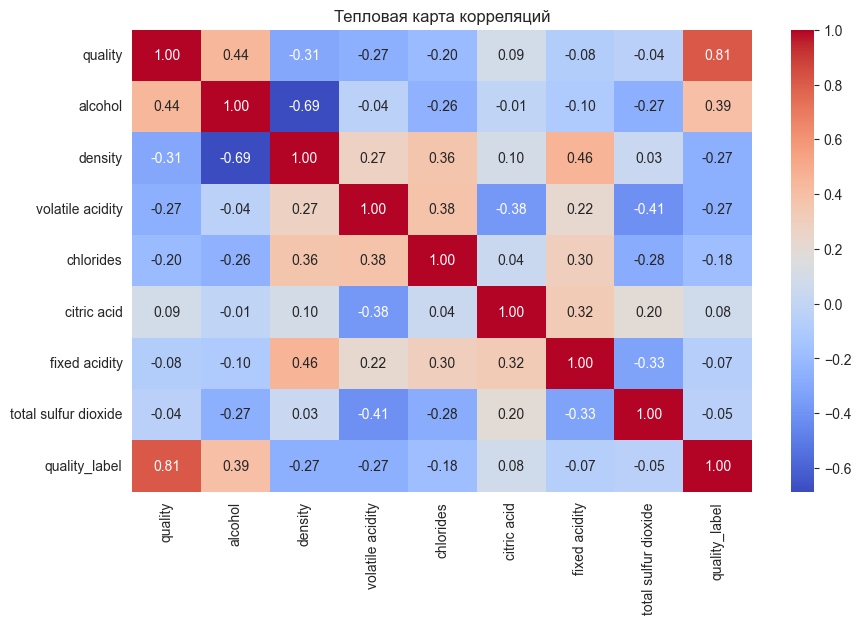

Признаки с наиболее сильной связью с целевой переменной:
quality                 0.814484
alcohol                 0.394676
density                -0.268876
volatile acidity       -0.267046
chlorides              -0.181908
citric acid             0.075739
fixed acidity          -0.067354
total sulfur dioxide   -0.047585
Name: quality_label, dtype: float64


In [13]:
corr_df = df.drop(columns=["wine_type"]).copy()
target_corr = corr_df.corr(numeric_only=True)["quality_label"].drop("quality_label").sort_values(key=lambda x: x.abs(), ascending=False)
top_features = target_corr.head(8).index.tolist()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_df[top_features + ["quality_label"]].corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Тепловая карта корреляций")
plt.show()

print("Признаки с наиболее сильной связью с целевой переменной:")
print(target_corr.head(8))

### 5. Обучение модели SVM

Используется классификатор `SVC` с `RBF`-ядром.

Основные параметры:
- `kernel="rbf"` — нелинейная граница разделения;
- `C=2.0` — штраф за ошибки классификации;
- `gamma="scale"` — способ задания параметра ядра.


In [14]:
svm_clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", SVC(kernel="rbf", C=2.0, gamma="scale"))
])

svm_clf.fit(X_train, y_train)
y_pred = svm_clf.predict(X_test)

In [15]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.7764
Precision: 0.8000
Recall: 0.8622
F1-score: 0.8300


In [16]:
print("Классификационный отчёт:")
print(classification_report(y_test, y_pred))

Классификационный отчёт:
              precision    recall  f1-score   support

           0       0.73      0.63      0.67       358
           1       0.80      0.86      0.83       617

    accuracy                           0.78       975
   macro avg       0.76      0.75      0.75       975
weighted avg       0.77      0.78      0.77       975



### 6. Матрица ошибок

Матрица ошибок показывает:
- сколько объектов модель классифицировала правильно;
- где именно были допущены ошибки.


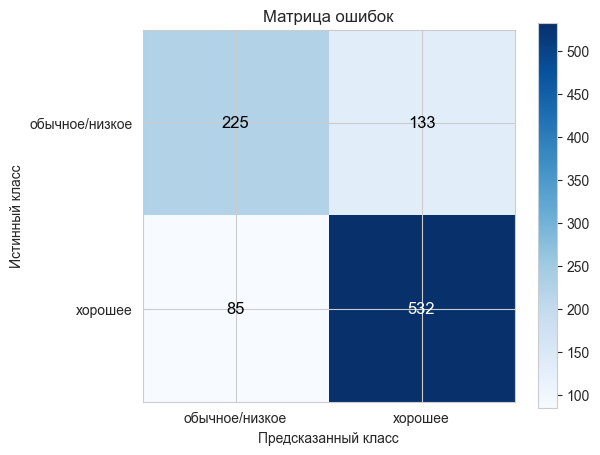

In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("Матрица ошибок")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.xticks([0, 1], ["обычное/низкое", "хорошее"])
plt.yticks([0, 1], ["обычное/низкое", "хорошее"])

threshold = cm.max() / 2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm[i, j] > threshold else "black"
        plt.text(j, i, cm[i, j], ha="center", va="center", color=color, fontsize=12)

plt.colorbar()
plt.show()

### 7. Графики результатов

Ниже показано:
- сравнение основных метрик;
- валидационная кривая по параметру `C`.


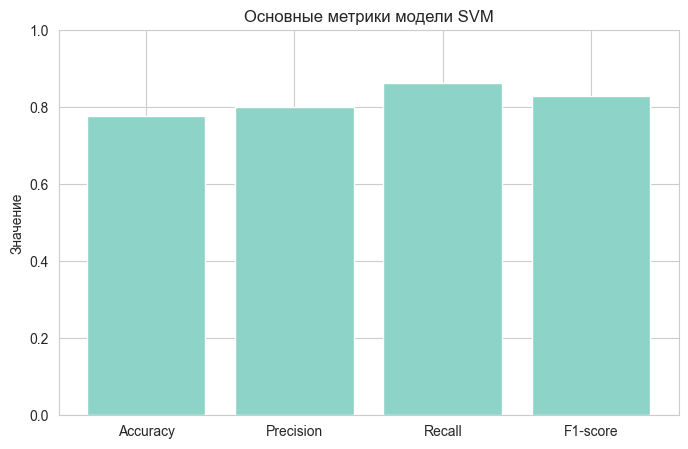

In [18]:
metrics_names = ["Accuracy", "Precision", "Recall", "F1-score"]
metrics_values = [accuracy, precision, recall, f1]

plt.figure(figsize=(8, 5))
plt.bar(metrics_names, metrics_values)
plt.ylim(0, 1)
plt.title("Основные метрики модели SVM")
plt.ylabel("Значение")
plt.show()

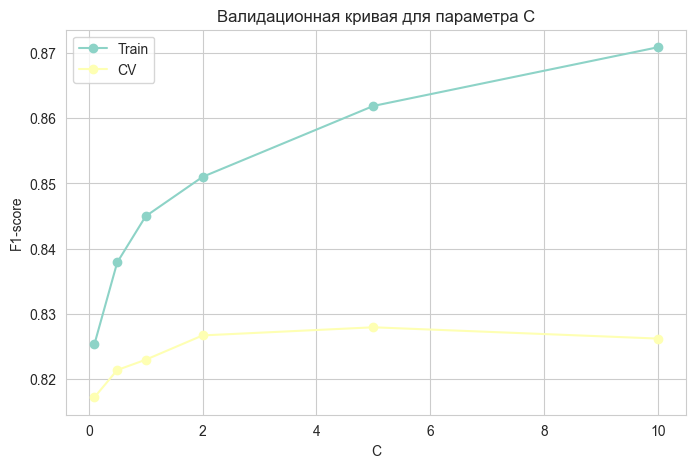

In [19]:
param_range = [0.1, 0.5, 1, 2, 5, 10]

train_scores, test_scores = validation_curve(
    svm_clf,
    X_train,
    y_train,
    param_name="model__C",
    param_range=param_range,
    cv=5,
    scoring="f1"
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(param_range, train_mean, marker="o", label="Train")
plt.plot(param_range, test_mean, marker="o", label="CV")
plt.xlabel("C")
plt.ylabel("F1-score")
plt.title("Валидационная кривая для параметра C")
plt.legend()
plt.show()

### 8. Вывод

В работе был рассмотрен метод машин опорных векторов для задачи бинарной классификации.

По физико-химическим характеристикам и типу вина модель определяла, относится ли вино к хорошему качеству. Перед обучением были выполнены предобработка, кодирование категориального признака и стандартизация числовых признаков.

По результатам эксперимента модель SVM показала хорошие значения основных метрик качества классификации. Это говорит о том, что метод машин опорных векторов подходит для данной задачи и способен эффективно разделять классы на выбранном датасете.
